# Módulo 3 — Regresión: Predecir el precio de autos usados

Solución de los **ejercicios del Módulo 3** del curso de Machine Learning para
Ingeniería de Software. Construimos, paso a paso, un modelo de regresión para
predecir el precio (`msrp`) de autos usados a partir de sus características, lo
evaluamos con **RMSE** y lo mejoramos con **feature engineering** y
**regularización (Ridge)**.

> Dataset: `data.csv` (precios de autos). El target es `msrp` y trabajamos con
> su transformación logarítmica `log1p(msrp)`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

Matplotlib is building the font cache; this may take a moment.


## Ejercicio 1: Preparación de datos

1. Cargar el dataset y mostrar las primeras 5 filas
2. Identificar columnas con valores nulos y decidir cómo tratarlos
3. Aplicar transformación log al target (precio)
4. Dividir en train (60%), validación (20%) y test (20%)

**1. Cargar el dataset y mostrar las primeras 5 filas**

In [2]:
df = pd.read_csv("data.csv")
print(f"Observaciones: {df.shape[0]}  |  Columnas: {df.shape[1]}")
df.head()

Observaciones: 11914  |  Columnas: 16


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


Normalizamos los nombres de columnas (minúsculas, sin espacios) y nos quedamos
con las columnas relevantes para el problema, tal como en la lección 3.2.

In [3]:
# Nombres de columna: minúsculas y sin espacios
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Columnas relevantes para predecir el precio
columnas = [
    "make", "model", "year", "engine_hp", "engine_cylinders",
    "transmission_type", "vehicle_size", "highway_mpg", "city_mpg", "msrp",
]
df = df[columnas]
df.head()

,make,model,year,engine_hp,engine_cylinders,transmission_type,vehicle_size,highway_mpg,city_mpg,msrp
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,Compact,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,Compact,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,Compact,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,Compact,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,Compact,28,18,34500


**2. Identificar columnas con valores nulos y decidir cómo tratarlos**

In [4]:
df.isnull().sum()

make                  0
model                 0
year                  0
engine_hp            69
engine_cylinders     30
transmission_type     0
vehicle_size          0
highway_mpg           0
city_mpg              0
msrp                  0
dtype: int64

Las únicas columnas con nulos son **`engine_hp`** y **`engine_cylinders`**, ambas
numéricas. Siguiendo la estrategia simple de la lección, las rellenamos con `0`.
(Una alternativa válida sería usar la mediana; mantenemos `0` por consistencia
con el material del módulo.)

In [5]:
df["engine_hp"] = df["engine_hp"].fillna(0)
df["engine_cylinders"] = df["engine_cylinders"].fillna(0)

print("Nulos restantes:", int(df.isnull().sum().sum()))

Nulos restantes: 0


**3. Aplicar transformación log al target (precio)**

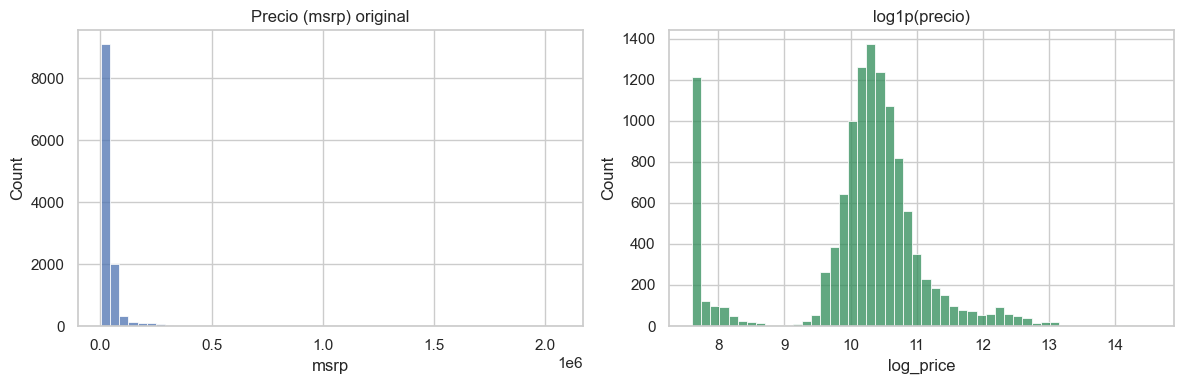

In [6]:
# El precio está muy sesgado a la derecha; log1p lo hace más simétrico,
# lo que favorece a los modelos lineales.
df["log_price"] = np.log1p(df["msrp"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["msrp"], bins=50, ax=axes[0])
axes[0].set_title("Precio (msrp) original")
sns.histplot(df["log_price"], bins=50, ax=axes[1], color="seagreen")
axes[1].set_title("log1p(precio)")
plt.tight_layout()
plt.show()

**4. Dividir en train (60%) / validación (20%) / test (20%)**

In [7]:
# 80% (train+val) y 20% test; luego 25% del 80% -> 20% val
df_train_full, df_test = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)
df_train, df_val = train_test_split(df_train_full, test_size=0.25, random_state=RANDOM_STATE)

# Copias independientes con índice reiniciado
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Target en escala log
y_train = df_train["log_price"].values
y_val = df_val["log_price"].values
y_test = df_test["log_price"].values

print(f"Train: {len(df_train)}  |  Val: {len(df_val)}  |  Test: {len(df_test)}")
print(
    f"Proporciones -> train {len(df_train)/len(df):.0%}, "
    f"val {len(df_val)/len(df):.0%}, test {len(df_test)/len(df):.0%}"
)

Train: 7148  |  Val: 2383  |  Test: 2383
Proporciones -> train 60%, val 20%, test 20%


## Ejercicio 2: Regresión lineal

1. Entrenar un modelo de regresión lineal con solo 2 features: `year` y `engine_hp`
2. Calcular el RMSE en validación
3. Agregar 3 features más y re-entrenar. ¿Mejoró el RMSE?
4. Interpretar los 3 pesos más grandes del modelo

Primero un **baseline**: predecir siempre la media del target.

In [8]:
y_pred_base = np.full_like(y_val, y_train.mean())
rmse_base = root_mean_squared_error(y_val, y_pred_base)
print(f"RMSE baseline (media): {rmse_base:.4f}")

RMSE baseline (media): 1.1296


**1 y 2. Modelo con 2 features (`year`, `engine_hp`) y RMSE en validación**

In [9]:
features_2 = ["year", "engine_hp"]

lr_2 = LinearRegression()
lr_2.fit(df_train[features_2], y_train)

rmse_2 = root_mean_squared_error(y_val, lr_2.predict(df_val[features_2]))
print(f"RMSE lineal (year, engine_hp): {rmse_2:.4f}")

RMSE lineal (year, engine_hp): 0.5332


**3. Agregar 3 features numéricas más y re-entrenar**

In [10]:
features_5 = ["year", "engine_hp", "engine_cylinders", "highway_mpg", "city_mpg"]

lr_5 = LinearRegression()
lr_5.fit(df_train[features_5], y_train)
rmse_5 = root_mean_squared_error(y_val, lr_5.predict(df_val[features_5]))

print(f"RMSE 2 features : {rmse_2:.4f}")
print(f"RMSE 5 features : {rmse_5:.4f}")
cambio = (rmse_2 - rmse_5) / rmse_2 * 100
print(f"¿Mejoró? {'Sí' if rmse_5 < rmse_2 else 'No'}  ({cambio:+.1f}% respecto al de 2 features)")

RMSE 2 features : 0.5332
RMSE 5 features : 0.5271
¿Mejoró? Sí  (+1.2% respecto al de 2 features)


**4. Interpretar los 3 pesos más grandes (por magnitud) del modelo de 5 features**

In [11]:
pesos = pd.Series(lr_5.coef_, index=features_5)
top3 = pesos.reindex(pesos.abs().sort_values(ascending=False).index).head(3)

print(f"Intercepto (bias): {lr_5.intercept_:.4f}\n")
print("Top 3 pesos por magnitud:")
print(top3.round(4))

Intercepto (bias): -174.6286

Top 3 pesos por magnitud:
year                0.0912
engine_cylinders    0.0701
city_mpg            0.0094
dtype: float64


**Cómo leer los pesos.** Como el target es `log1p(precio)`, cada peso indica el
cambio en el *log* del precio cuando esa feature sube 1 unidad (con las demás
constantes). Los 3 de mayor magnitud en este modelo son:

- **`year` (+0.0912)**: cada año más nuevo sube el log-precio ~0.091 → los autos
  más recientes son más caros.
- **`engine_cylinders` (+0.0701)**: cada cilindro adicional incrementa el
  log-precio ~0.070.
- **`city_mpg` (+0.0094)**: efecto pequeño y positivo del rendimiento en ciudad.

Que dominen `year` y `engine_cylinders` (y no `engine_hp`) se debe a la **escala**
de cada variable: `year` y los cilindros varían en rangos pequeños, así que su
efecto *por unidad* es grande; `engine_hp` varía en cientos, por lo que su peso
por unidad es diminuto aunque la potencia sí influya en el precio.

## Ejercicio 3: Feature engineering

1. Crear la variable `antiguedad = 2024 - year`
2. Aplicar One-Hot Encoding a la columna `make` (marca)
3. Entrenar un modelo con todas las features (numéricas + encoded)
4. Comparar el RMSE con el modelo del ejercicio 2

**1. Crear la variable `antiguedad = 2024 - year`**

In [12]:
# 'antiguedad' es una transformación lineal de 'year', así que la usamos EN LUGAR
# de 'year' entre las numéricas (incluir ambas sería colineal y redundante).
for d in (df_train, df_val, df_test):
    d["antiguedad"] = 2024 - d["year"]

df_train[["year", "antiguedad"]].head()

,year,antiguedad
0,2011,13
1,2009,15
2,2012,12
3,2016,8
4,2009,15


**2 y 3. One-Hot Encoding de `make` + modelo con todas las features**

Usamos un `ColumnTransformer` que deja pasar las numéricas y aplica
`OneHotEncoder` a `make`. Lo envolvemos en un `Pipeline` para evitar fugas de
datos (el encoder se ajusta solo con train) y `handle_unknown="ignore"` cubre
marcas no vistas en validación/test.

In [13]:
num_features = ["antiguedad", "engine_hp", "engine_cylinders", "highway_mpg", "city_mpg"]
cat_features = ["make"]


def construir_modelo(estimador):
    """Pipeline: One-Hot Encoding de 'make' + numéricas -> estimador."""
    preprocesador = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ]
    )
    return Pipeline([("prep", preprocesador), ("model", estimador)])


modelo_full = construir_modelo(LinearRegression())
modelo_full.fit(df_train, y_train)
rmse_full = root_mean_squared_error(y_val, modelo_full.predict(df_val))

n_cols = modelo_full.named_steps["prep"].transform(df_train).shape[1]
print(f"Número de features tras One-Hot Encoding: {n_cols}")
print(f"RMSE (todas las features): {rmse_full:.4f}")

Número de features tras One-Hot Encoding: 53
RMSE (todas las features): 0.4479


**4. Comparar con los modelos del ejercicio 2**

In [14]:
comparacion_3 = pd.DataFrame(
    {
        "Modelo": ["Lineal (2 features)", "Lineal (5 numéricas)", "Lineal (todas + OHE make)"],
        "RMSE val": [rmse_2, rmse_5, rmse_full],
    }
)
comparacion_3.round(4)

,Modelo,RMSE val
0,Lineal (2 features),0.5332
1,Lineal (5 numéricas),0.5271
2,Lineal (todas + OHE make),0.4479


## Ejercicio 4: Regularización

1. Entrenar modelos Ridge con `alpha = [0.001, 0.01, 0.1, 1, 10, 100]`
2. Graficar alpha vs RMSE
3. ¿Cuál es el mejor alpha?
4. Entrenar el modelo final (con el mejor alpha) usando train + val
5. Reportar el RMSE en test

**1. Ridge para distintos valores de alpha**

In [15]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
rmses_ridge = []

for alpha in alphas:
    modelo = construir_modelo(Ridge(alpha=alpha))
    modelo.fit(df_train, y_train)
    score = root_mean_squared_error(y_val, modelo.predict(df_val))
    rmses_ridge.append(score)
    print(f"alpha={alpha:>7}: RMSE val = {score:.4f}")

alpha=  0.001: RMSE val = 0.4573
alpha=   0.01: RMSE val = 0.4573
alpha=    0.1: RMSE val = 0.4573
alpha=      1: RMSE val = 0.4545
alpha=     10: RMSE val = 0.4638
alpha=    100: RMSE val = 0.4898


**2. Graficar alpha vs RMSE**

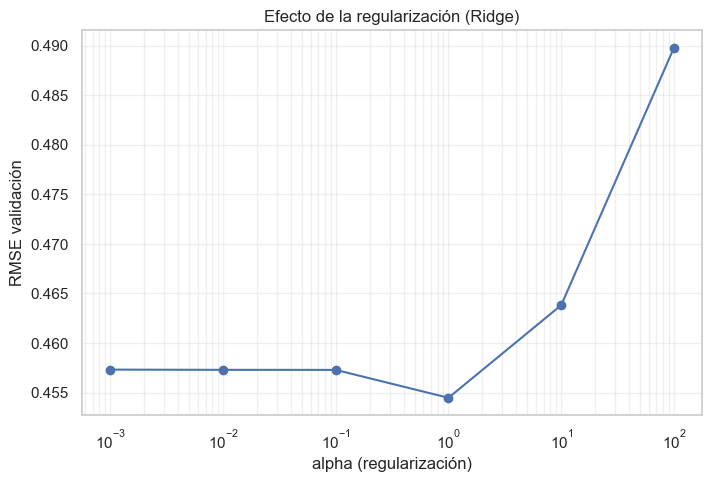

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(alphas, rmses_ridge, marker="o")
plt.xscale("log")
plt.xlabel("alpha (regularización)")
plt.ylabel("RMSE validación")
plt.title("Efecto de la regularización (Ridge)")
plt.grid(True, which="both", alpha=0.3)
plt.show()

**3. ¿Cuál es el mejor alpha?**

In [17]:
idx_best = int(np.argmin(rmses_ridge))
best_alpha = alphas[idx_best]
rmse_ridge_val = rmses_ridge[idx_best]
print(f"Mejor alpha: {best_alpha}  (RMSE val = {rmse_ridge_val:.4f})")

Mejor alpha: 1  (RMSE val = 0.4545)


**4 y 5. Modelo final con train + val, y RMSE en test (evaluado una sola vez)**

In [18]:
df_train_val = pd.concat([df_train, df_val], ignore_index=True)
y_train_val = np.concatenate([y_train, y_val])

modelo_final = construir_modelo(Ridge(alpha=best_alpha))
modelo_final.fit(df_train_val, y_train_val)

rmse_test = root_mean_squared_error(y_test, modelo_final.predict(df_test))
print(f"Modelo final -> Ridge(alpha={best_alpha})")
print(f"RMSE en TEST: {rmse_test:.4f}")

Modelo final -> Ridge(alpha=1)
RMSE en TEST: 0.4523


## Ejercicio 5: Comparación final

Tabla resumen con todos los modelos entrenados.

In [19]:
resumen = pd.DataFrame(
    [
        {"Modelo": "Baseline (media)",    "Features": "—",               "RMSE val": rmse_base},
        {"Modelo": "Lineal (2 features)", "Features": "year, hp",        "RMSE val": rmse_2},
        {"Modelo": "Lineal (todas)",      "Features": "todas + OHE make", "RMSE val": rmse_full},
        {"Modelo": "Ridge (mejor alpha)", "Features": "todas + OHE make", "RMSE val": rmse_ridge_val},
    ]
)
resumen["RMSE val"] = resumen["RMSE val"].round(4)
resumen = resumen.sort_values("RMSE val", ascending=False).reset_index(drop=True)
resumen

,Modelo,Features,RMSE val
0,Baseline (media),—,1.1296
1,Lineal (2 features),"year, hp",0.5332
2,Ridge (mejor alpha),todas + OHE make,0.4545
3,Lineal (todas),todas + OHE make,0.4479


### Conclusiones

- Con solo 2 features (`year`, `engine_hp`) el RMSE baja de **1.13** (baseline de
  la media) a **0.53**.
- Sumar más features numéricas ayuda poco (0.53 → 0.53), pero el **One-Hot
  Encoding de la marca** es el salto grande: **0.53 → 0.45**. El feature
  engineering aporta más que cambiar de algoritmo.
- La **regularización Ridge** aquí **no mejora** a la regresión lineal simple
  (mejor `alpha = 1` con RMSE val **0.4545** frente a **0.4479** de OLS). Tiene
  sentido: con estas ~53 columnas la matriz no es inestable ni hay sobreajuste
  marcado, así que penalizar los pesos solo añade un pequeño sesgo. Ridge brilla
  cuando hay muchas dummies colineales o pocos datos.
- El modelo final (Ridge con `alpha = 1`, entrenado en train + val) logra
  **RMSE = 0.4523 en test**, muy cerca del de validación: el modelo
  **generaliza** bien a datos no vistos.